/tmp/ipykernel_916277/2940112513.py:83: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pc = ax.pcolormesh(X, Y, omega_hat, cmap=cmap, norm=norm, shading="auto", zorder=1)


Saved figs/cavity_disk.{pdf,png} and figs/cavity_profiles.{pdf,png}


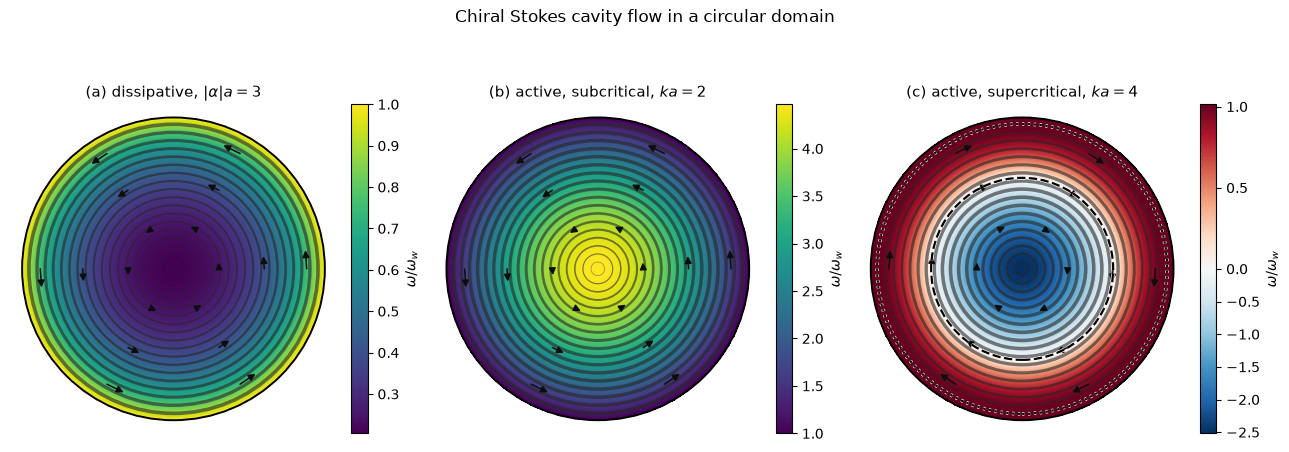

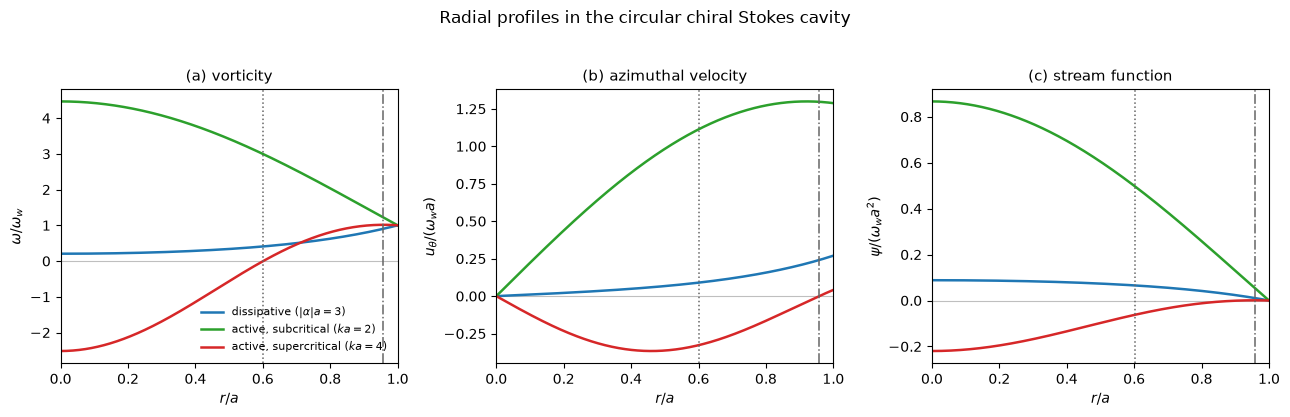

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.patches import Circle
from scipy.special import i0, i1, j0, j1, jn_zeros # Bessel functions

# ----------------------------------------------------------------------
# Physics core (identical to manuscript), already verified)
# ----------------------------------------------------------------------
def cavity_fields(rho, group, branch):
    rho = np.asarray(rho, dtype=float)
    if branch == "dissipative":
        beta = group
        omega_hat = i0(beta * rho) / i0(beta)
        u_theta_hat = i1(beta * rho) / (beta * i0(beta))
        psi_hat = (1.0 - i0(beta * rho) / i0(beta)) / beta**2
    elif branch == "active":
        kappa = group
        omega_hat = j0(kappa * rho) / j0(kappa)
        u_theta_hat = j1(kappa * rho) / (kappa * j0(kappa))
        psi_hat = (j0(kappa * rho) / j0(kappa) - 1.0) / kappa**2
    else:
        raise ValueError("branch must be 'dissipative' or 'active'")
    return omega_hat, u_theta_hat, psi_hat


BETA_DISS = 3.0
KAPPA_SUB = 2.0
KAPPA_SUPER = 4.0

# ----------------------------------------------------------------------
# Figure 1: cavity_disk (2D flow, 3 panels)
# ----------------------------------------------------------------------
def polar_grid(a=1.0, n_r=240, n_theta=361):
    r = np.linspace(0.0, a, n_r)
    theta = np.linspace(0.0, 2 * np.pi, n_theta)
    R, TH = np.meshgrid(r, theta)
    X, Y = R * np.cos(TH), R * np.sin(TH)
    return R, TH, X, Y


def draw_streamline_circles(ax, a, group, branch, n_circles=18,
                             lw_range=(0.4, 2.6), color="0.15", alpha=0.6,
                             skip_frac=0.045):
    rho_c = np.linspace(skip_frac, 1 - skip_frac, n_circles)
    _, u_hat, _ = cavity_fields(rho_c, group, branch)
    s = np.sqrt(np.abs(u_hat))
    s_norm = (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else np.zeros_like(s)
    lws = lw_range[0] + s_norm * (lw_range[1] - lw_range[0])
    for rc, lw in zip(rho_c, lws):
        ax.add_patch(Circle((0, 0), rc * a, fill=False, edgecolor=color,
                             linewidth=lw, alpha=alpha, zorder=2))


def add_flow_arrows(ax, a, group, branch, radii_frac=(0.3, 0.6, 0.88),
                     n_angles=6, color="0.05"):
    for rf in radii_frac:
        _, u_hat, _ = cavity_fields(np.array([rf]), group, branch)
        sense = 1.0 if u_hat[0] >= 0 else -1.0
        r = rf * a
        for theta0 in np.linspace(0, 2 * np.pi, n_angles, endpoint=False):
            dth = sense * 0.14
            p0 = (r * np.cos(theta0), r * np.sin(theta0))
            p1 = (r * np.cos(theta0 + dth), r * np.sin(theta0 + dth))
            ax.annotate("", xy=p1, xytext=p0, zorder=3,
                        arrowprops=dict(arrowstyle="-|>", color=color, lw=1.1,
                                        shrinkA=0, shrinkB=0))


def plot_disk_panel(ax, group, branch, label, mark_zeros=False, a=1.0,
                     cmap_seq="viridis"):
    R, TH, X, Y = polar_grid(a=a)
    rho = R / a
    omega_hat, u_hat, psi_hat = cavity_fields(rho, group, branch)

    vmin, vmax = np.nanmin(omega_hat), np.nanmax(omega_hat)
    if vmin < 0 < vmax:
        norm, cmap = TwoSlopeNorm(vcenter=0.0, vmin=vmin, vmax=vmax), "RdBu_r"
    else:
        norm, cmap = Normalize(vmin=vmin, vmax=vmax), cmap_seq

    pc = ax.pcolormesh(X, Y, omega_hat, cmap=cmap, norm=norm, shading="auto", zorder=1)
    draw_streamline_circles(ax, a, group, branch)
    add_flow_arrows(ax, a, group, branch)

    if mark_zeros:
        j01, _ = jn_zeros(0, 2)
        j11 = jn_zeros(1, 1)[0]
        kappa = group
        r1, r1p = j01 / kappa, j11 / kappa
        halo = [pe.withStroke(linewidth=2.6, foreground="white")]
        ax.add_patch(Circle((0, 0), r1 * a, fill=False, edgecolor="k", linestyle="--",
                             linewidth=1.6, zorder=4, path_effects=halo))
        ax.add_patch(Circle((0, 0), r1p * a, fill=False, edgecolor="k", linestyle=":",
                             linewidth=1.6, zorder=4, path_effects=halo))

    ax.add_patch(Circle((0, 0), a, fill=False, edgecolor="k", linewidth=1.4, zorder=5))
    ax.set_xlim(-1.08 * a, 1.08 * a)
    ax.set_ylim(-1.08 * a, 1.08 * a)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(label, fontsize=11)
    cb = plt.colorbar(pc, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(r"$\omega/\omega_w$")
    return pc


fig1, axes1 = plt.subplots(1, 3, figsize=(13, 4.6))
plot_disk_panel(axes1[0], BETA_DISS, "dissipative",
                f"(a) dissipative, $|\\alpha|a={BETA_DISS:g}$")
plot_disk_panel(axes1[1], KAPPA_SUB, "active",
                f"(b) active, subcritical, $ka={KAPPA_SUB:g}$")
plot_disk_panel(axes1[2], KAPPA_SUPER, "active",
                f"(c) active, supercritical, $ka={KAPPA_SUPER:g}$", mark_zeros=True)
fig1.suptitle("Chiral Stokes cavity flow in a circular domain", y=1.03)
fig1.tight_layout()
fig1.savefig("figs/cavity_disk.pdf", bbox_inches="tight")
fig1.savefig("figs/cavity_disk.png", dpi=170, bbox_inches="tight")
#plt.close(fig1)
n

# ----------------------------------------------------------------------
# Figure 2: cavity_profiles (radial profiles, 3 panels)
# ----------------------------------------------------------------------
rho = np.linspace(0, 1, 600)
regimes = [
    dict(group=BETA_DISS, branch="dissipative",
         label=f"dissipative ($|\\alpha|a={BETA_DISS:g}$)", color="tab:blue"),
    dict(group=KAPPA_SUB, branch="active",
         label=f"active, subcritical ($ka={KAPPA_SUB:g}$)", color="tab:green"),
    dict(group=KAPPA_SUPER, branch="active",
         label=f"active, supercritical ($ka={KAPPA_SUPER:g}$)", color="tab:red"),
]

fig2, axes2 = plt.subplots(1, 3, figsize=(13, 4))
ylabels = [r"$\omega/\omega_w$", r"$u_\theta/(\omega_w a)$", r"$\psi/(\omega_w a^2)$"]
titles = ["(a) vorticity", "(b) azimuthal velocity", "(c) stream function"]

for reg in regimes:
    oh, uh, ph = cavity_fields(rho, reg["group"], reg["branch"])
    for ax, field in zip(axes2, (oh, uh, ph)):
        ax.plot(rho, field, color=reg["color"], label=reg["label"], lw=1.8)

j01, _ = jn_zeros(0, 2)
j11 = jn_zeros(1, 1)[0]
r1, r1p = j01 / KAPPA_SUPER, j11 / KAPPA_SUPER
for ax, yl, tt in zip(axes2, ylabels, titles):
    ax.axvline(r1, color="0.4", linestyle=":", linewidth=1.1)
    ax.axvline(r1p, color="0.4", linestyle="-.", linewidth=1.1)
    ax.axhline(0, color="0.75", linewidth=0.8, zorder=0)
    ax.set_xlabel(r"$r/a$")
    ax.set_xlim(0, 1)
    ax.set_ylabel(yl)
    ax.set_title(tt, fontsize=11)

axes2[0].legend(fontsize=8, frameon=False, loc="best")
fig2.suptitle("Radial profiles in the circular chiral Stokes cavity", y=1.03)
fig2.tight_layout()
fig2.savefig("figs/cavity_profiles.pdf", bbox_inches="tight")
fig2.savefig("figs/cavity_profiles.png", dpi=170, bbox_inches="tight")
#plt.close(fig2)

print("Saved figs/cavity_disk.{pdf,png} and figs/cavity_profiles.{pdf,png}")